# Задача 2. Статистические модели (statsforecast)

Сравнение ≥5 методов (auto + manual + baseline), rolling backtest, анализ остатков, hold-out 48 ч.

**Вывод по задаче 2** — раздел 4 в `README.md`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from statsforecast import StatsForecast
from statsforecast.models import (
    ARIMA,
    AutoARIMA,
    AutoETS,
    AutoTheta,
    Naive,
    SeasonalNaive,
    Theta,
)
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

from src.config import FORECAST_HORIZON, SEASON
from src.metrics import evaluate, metrics_table
from src.stats import cross_validate_models, cv_by_window, cv_summary

H = FORECAST_HORIZON
CV_H = 24
N_WINDOWS = 5
CV_STEP = 24

In [2]:
train_df = pd.read_parquet('__output__/train.parquet')
test_df = pd.read_parquet('__output__/test.parquet')

In [3]:
def df2data(df: pd.DataFrame):
    return pd.DataFrame({
        'unique_id': df['unique_id'].copy(),
        'ds': df.index.values.copy(),
        'y': df['AC_POWER'].copy()
    })

In [4]:
train_data = df2data(train_df)
test_data = df2data(test_df)

# Naive

In [5]:
naive_models = [
    Naive(),
    SeasonalNaive(season_length=SEASON)
]

sf_naive = StatsForecast(
    models=naive_models,
    freq='h'
)

In [6]:
naive_forecasts = sf_naive.forecast(df=train_data, h=H, fitted=True)
naive_train_forecasts = sf_naive.forecast_fitted_values()

# Авто-модели

In [7]:
auto_models = [
    AutoARIMA(season_length=SEASON, max_p=3, max_q=3, max_P=1, max_Q=1),
    AutoETS(season_length=SEASON),
    AutoTheta(season_length=SEASON)
]

auto_sf = StatsForecast(
    models=auto_models,
    freq='h',
    n_jobs=10
)

In [8]:
auto_forecasts = auto_sf.forecast(df=train_data, h=H, fitted=True)
auto_train_forecasts = auto_sf.forecast_fitted_values()

## Ручная настройка (ARIMA, Theta, CES)

In [9]:
manual_models = [
    ARIMA(
        order=(2, 1, 2),
        season_length=SEASON
    ),
    Theta(
        season_length=SEASON,
        decomposition_type='multiplicative'
    )
]

manual_sf = StatsForecast(models=manual_models, freq='h', n_jobs=-1)

In [10]:
manual_forecasts = manual_sf.forecast(df=train_data, h=H, fitted=True)
manual_train_forecasts = manual_sf.forecast_fitted_values()

# Test

Метрики — на **всех** наблюдениях и с **`no_zeros=True`** (часы с выработкой > 0). Ночные нули искажают MAPE на полном ряду.

In [11]:
def print_metrics(
    data: pd.DataFrame,
    forecast: pd.DataFrame,
    models: list,
    no_zeros=False
):
    data = data.merge(
        forecast,
        on=[
            'unique_id',
            'ds'
        ]
    )

    eval_rows = []
    for m in models:
        m_name = m.alias

        metrics = evaluate(data['y'], data[m_name], no_zeros)
        metrics['model'] = m_name
        eval_rows.append(metrics)

    results_auto = metrics_table(eval_rows)

    return results_auto

## Naive

In [12]:
print_metrics(
    test_data,
    naive_forecasts,
    naive_models
)

,MAE,RMSE,MAPE,sMAPE
model,,,,
SeasonalNaive,5860.657587,10989.593847,28.648802,18.980735
Naive,19887.051661,32577.206719,54.166667,108.333333


In [13]:
print_metrics(
    test_data,
    naive_forecasts,
    naive_models,
    True
)

,MAE,RMSE,MAPE,sMAPE
model,,,,
SeasonalNaive,10819.675546,14931.917674,52.890096,35.041357
Naive,36714.556913,44263.707605,100.000000,200.000000


## Auto

In [14]:
print_metrics(
    test_data,
    auto_forecasts,
    auto_models
)

,MAE,RMSE,MAPE,sMAPE
model,,,,
AutoETS,5267.594130,8682.154858,6.559906e+10,109.440486
AutoTheta,4910.524014,9048.034779,3.615114e+09,106.683412
AutoARIMA,5152.091235,9852.037326,1.948370e+06,43.854623


In [15]:
print_metrics(
    test_data,
    auto_forecasts,
    auto_models,
    True
)

,MAE,RMSE,MAPE,sMAPE
model,,,,
AutoETS,8513.729618,11703.569734,40.196744,32.813206
AutoTheta,8998.842234,12293.510957,41.689115,27.723221
AutoARIMA,9511.517080,13386.282724,50.083894,32.257127


## Manual

In [16]:
print_metrics(
    test_data,
    manual_forecasts,
    manual_models
)

,MAE,RMSE,MAPE,sMAPE
model,,,,
Theta,4909.676034,9040.294569,4.269145e+09,106.656122
ARIMA,17809.634531,25231.321133,3.636172e+11,158.762790


In [17]:
print_metrics(
    test_data,
    manual_forecasts,
    manual_models,
    True,
)

,MAE,RMSE,MAPE,sMAPE
model,,,,
Theta,8985.202305,12282.919612,41.598369,27.672841
ARIMA,26166.392394,32479.886371,169.914889,123.869765


## Plots

In [18]:
def plot_forecast(
    data: pd.DataFrame,
    forecast: pd.DataFrame,
    models: list
):
    data = data.merge(
        forecast,
        on=[
            'unique_id',
            'ds'
        ]
    )

    fig, axes = plt.subplots(len(models), 1, figsize=(10, 2*len(models)))

    for ax, m in zip(axes, models):
        m_name = m.alias

        ax.plot(
            data['ds'],
            data['y'],
            label='True'
        )

        ax.plot(
            forecast['ds'],
            forecast[m_name],
            label='Predict'
        )

        ax.legend()
        ax.set_title(f'Model - {m_name}')

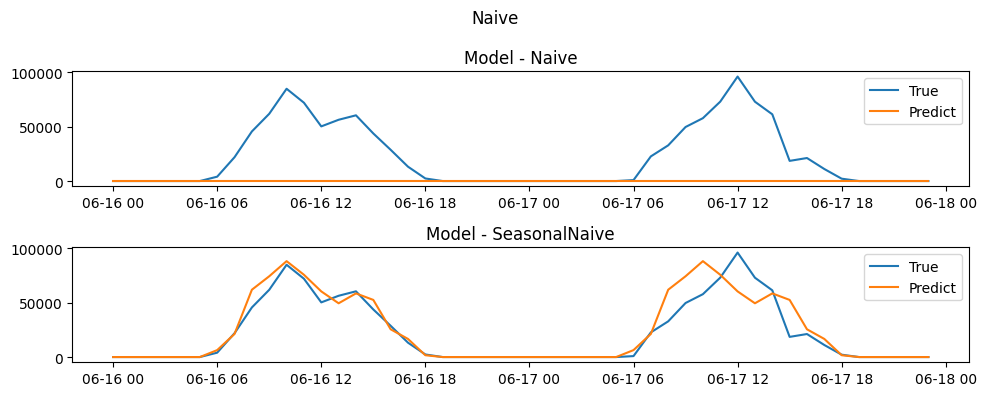

In [19]:
plot_forecast(
    test_data[test_data['unique_id'] == '1'],
    naive_forecasts[naive_forecasts['unique_id'] == '1'],
    naive_models
)

plt.suptitle('Naive')

plt.tight_layout()
plt.show()

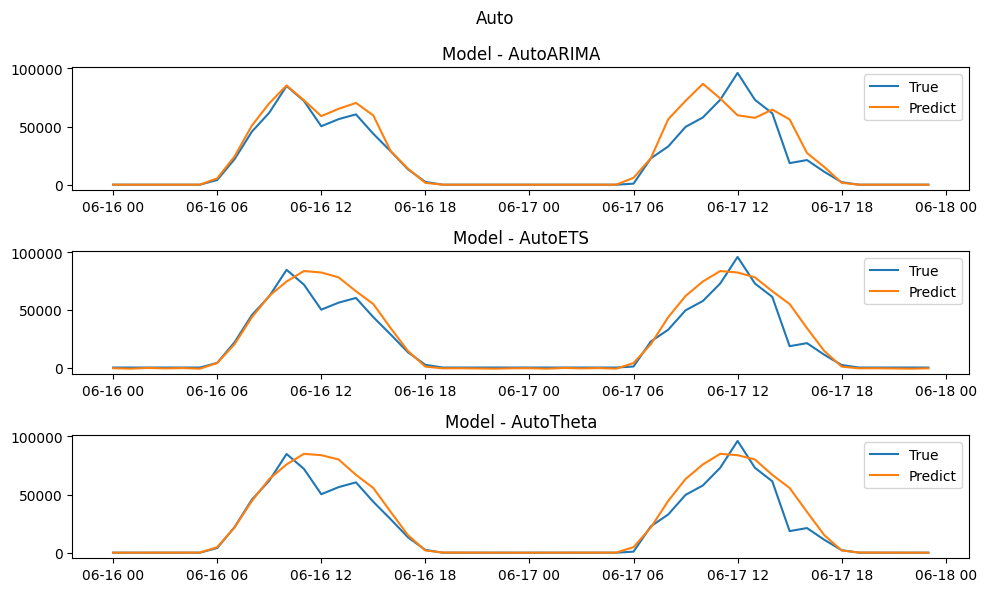

In [21]:
plot_forecast(
    test_data[test_data['unique_id'] == '1'],
    auto_forecasts[auto_forecasts['unique_id'] == '1'],
    auto_models
)

plt.suptitle('Auto')

plt.tight_layout()
plt.show()

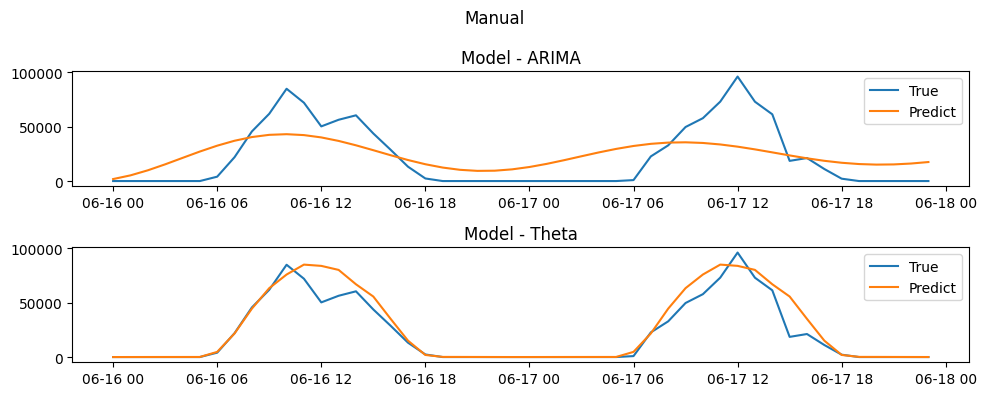

In [22]:
plot_forecast(
    test_data[test_data['unique_id'] == '1'],
    manual_forecasts[manual_forecasts['unique_id'] == '1'],
    manual_models
)

plt.suptitle('Manual')

plt.tight_layout()
plt.show()

## Анализ остатков

In-sample диагностика для моделей с лучшим RMSE на hold-out: проверяем, что остатки не имеют автокорреляции (Ljung–Box) и приближаются к нормальности (Q–Q plot).

In [23]:
def plot_residual_diagnostics(
    ds,
    y,
    pred,
    model_name: str
):
    '''Графики остатков: временной ряд, гистограмма, ACF, Q-Q.'''
    res = y - pred
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    axes[0, 0].plot(ds, res, linewidth=0.8)
    axes[0, 0].axhline(0, color='k', linewidth=0.5)
    axes[0, 0].set_title(f'Остатки во времени — {model_name}')
    axes[0, 0].set_xlabel('ds')
    axes[0, 0].tick_params(axis='x', rotation=45)

    sns.histplot(res, kde=True, ax=axes[0, 1])
    axes[0, 1].set_title('Распределение остатков')

    plot_acf(res, lags=48, ax=axes[1, 0])
    axes[1, 0].set_title('ACF остатков')

    stats.probplot(res, dist='norm', plot=axes[1, 1])
    axes[1, 1].set_title('Q-Q plot (нормальность)')

    plt.tight_layout()
    plt.show()

    lb = acorr_ljungbox(res, lags=[24, 48], return_df=True)
    print(f'Ljung–Box ({model_name}):')
    display(lb)

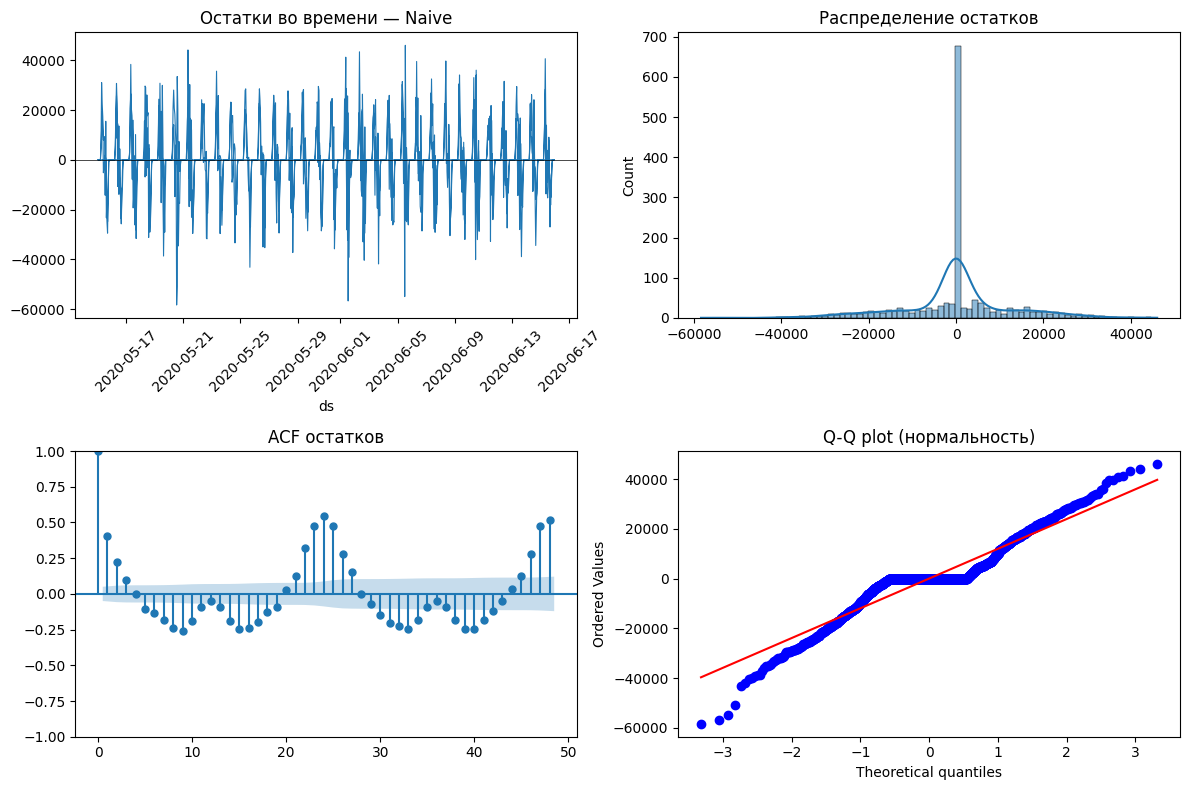

Ljung–Box (Naive):


,lb_stat,lb_pvalue
24,2056.225287,0.0
48,4201.222370,0.0


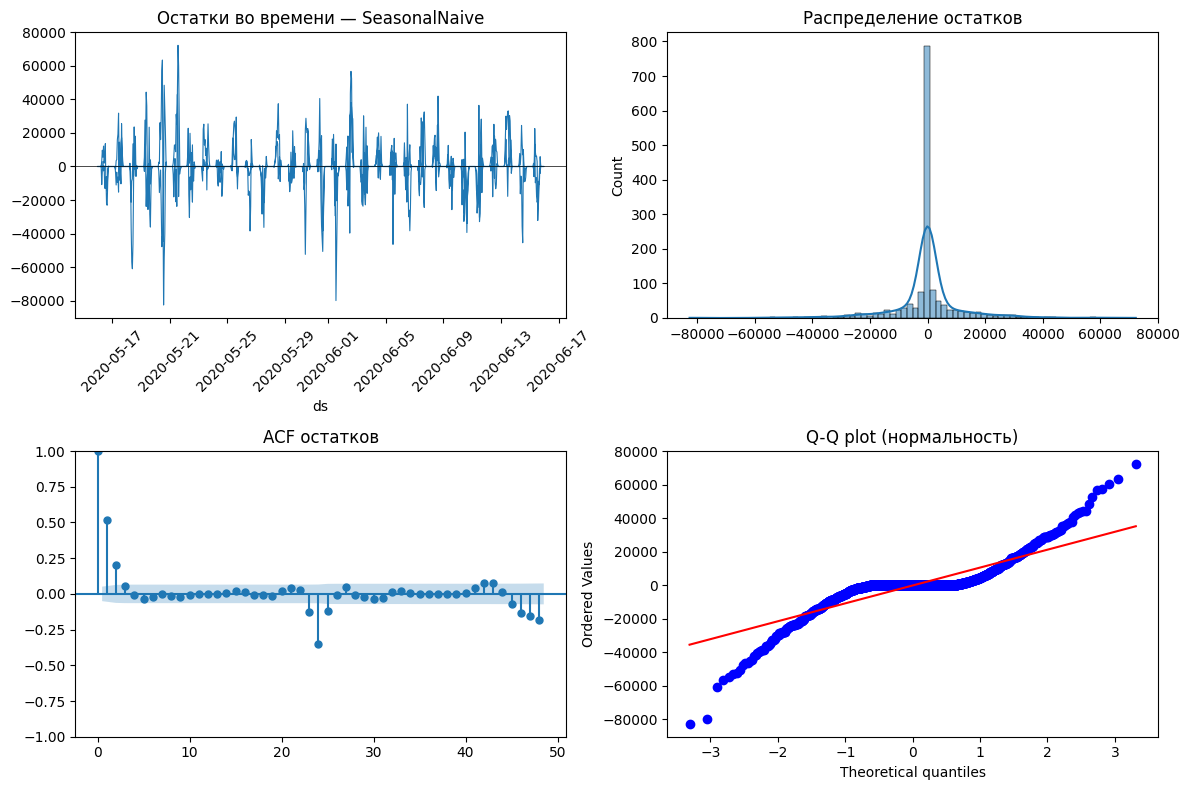

Ljung–Box (SeasonalNaive):


,lb_stat,lb_pvalue
24,688.438386,6.692625e-130
48,860.965505,1.721831e-149


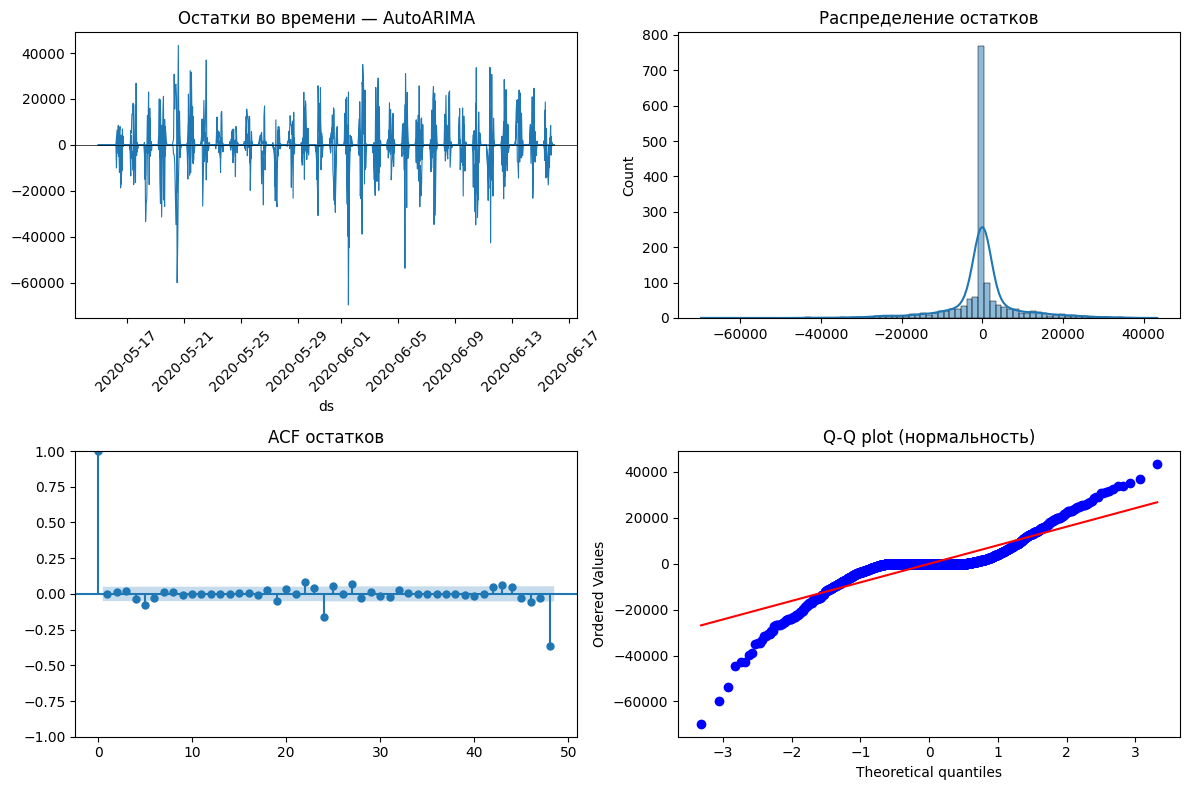

Ljung–Box (AutoARIMA):


,lb_stat,lb_pvalue
24,74.566519,4.356916e-07
48,322.078486,2.984656e-42


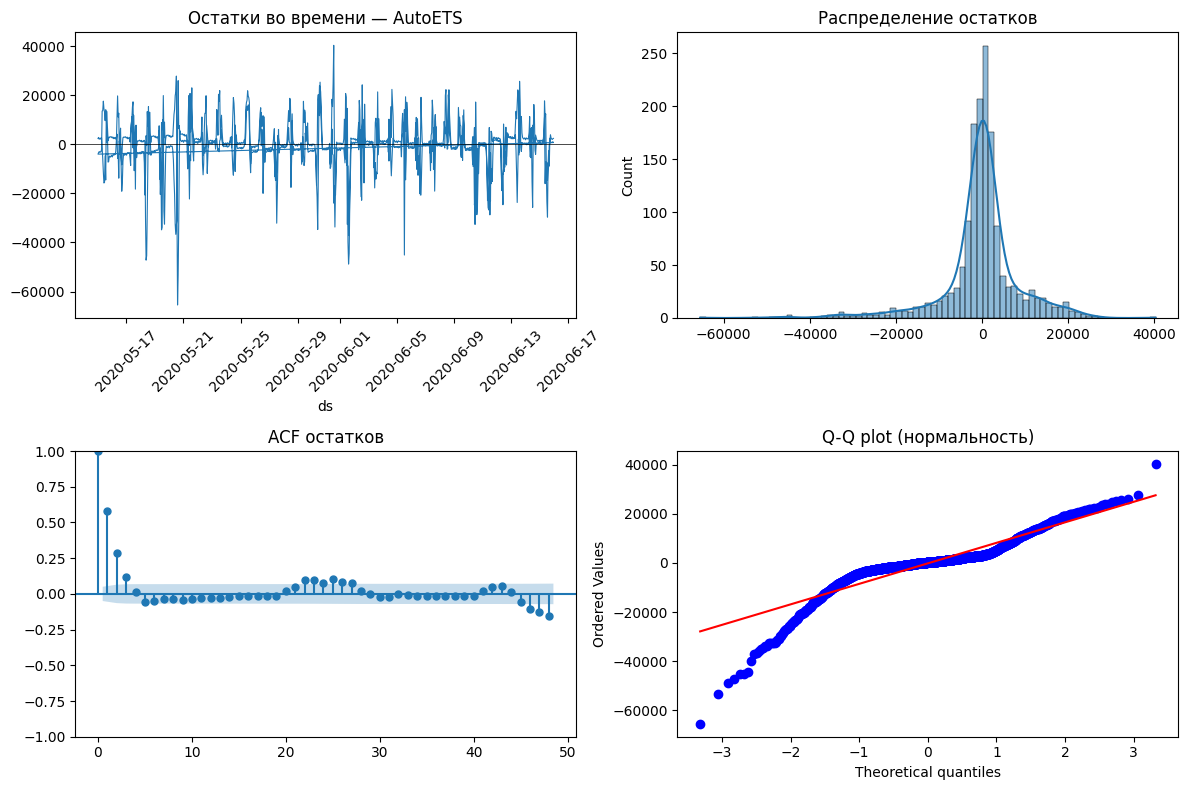

Ljung–Box (AutoETS):


,lb_stat,lb_pvalue
24,727.612739,3.824852e-138
48,867.886564,6.499551e-151


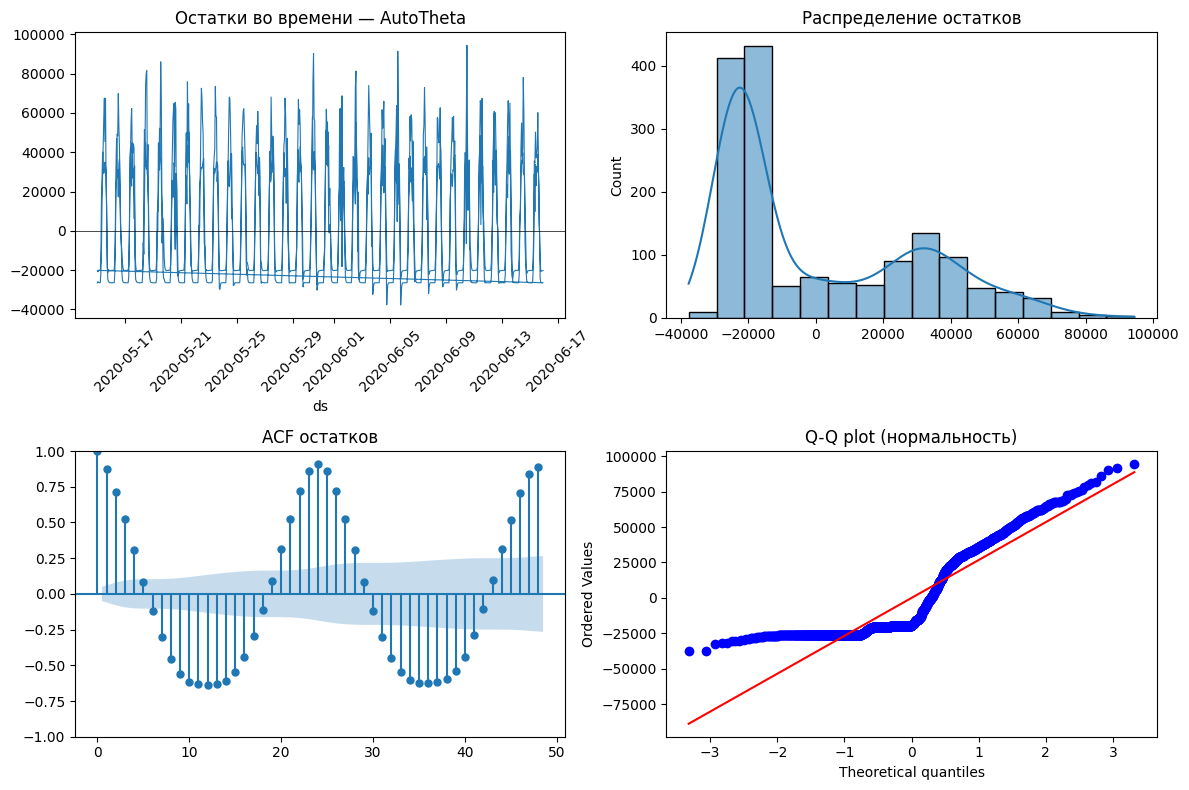

Ljung–Box (AutoTheta):


,lb_stat,lb_pvalue
24,11314.761423,0.0
48,22462.790396,0.0


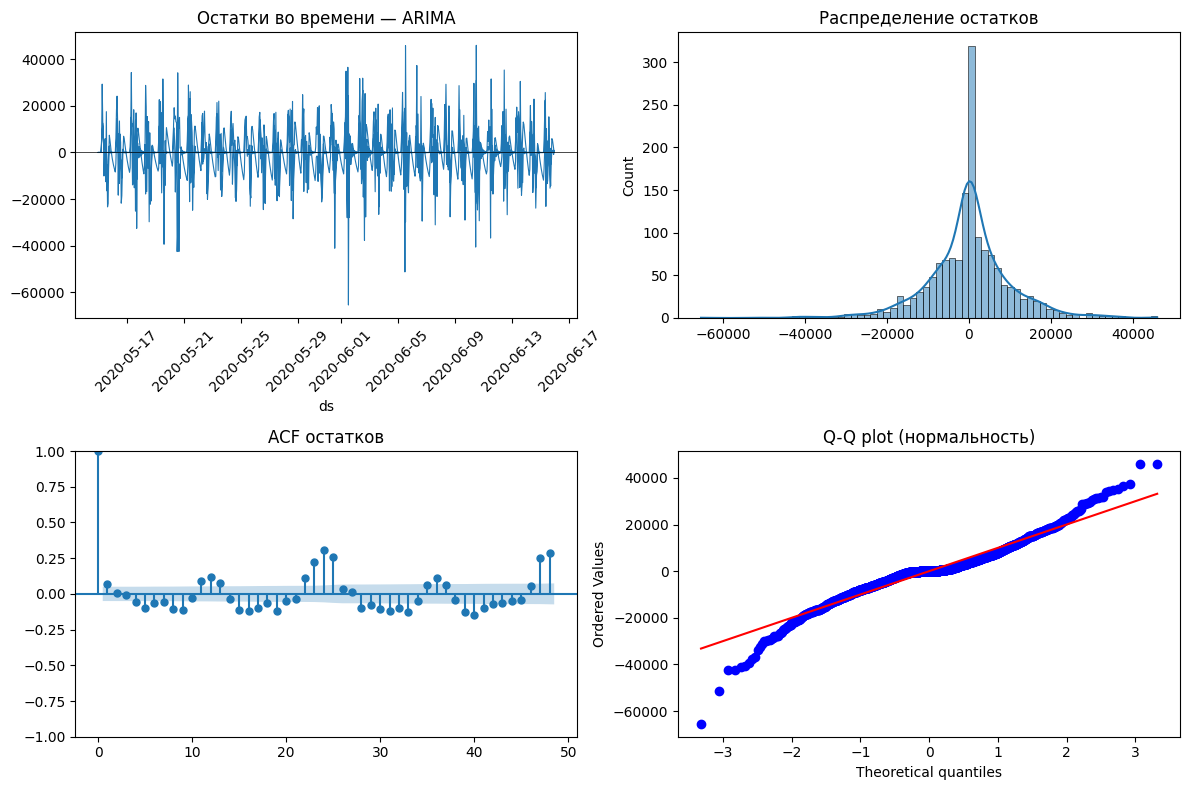

Ljung–Box (ARIMA):


,lb_stat,lb_pvalue
24,457.555083,1.039605e-81
48,1042.456331,5.397468e-187


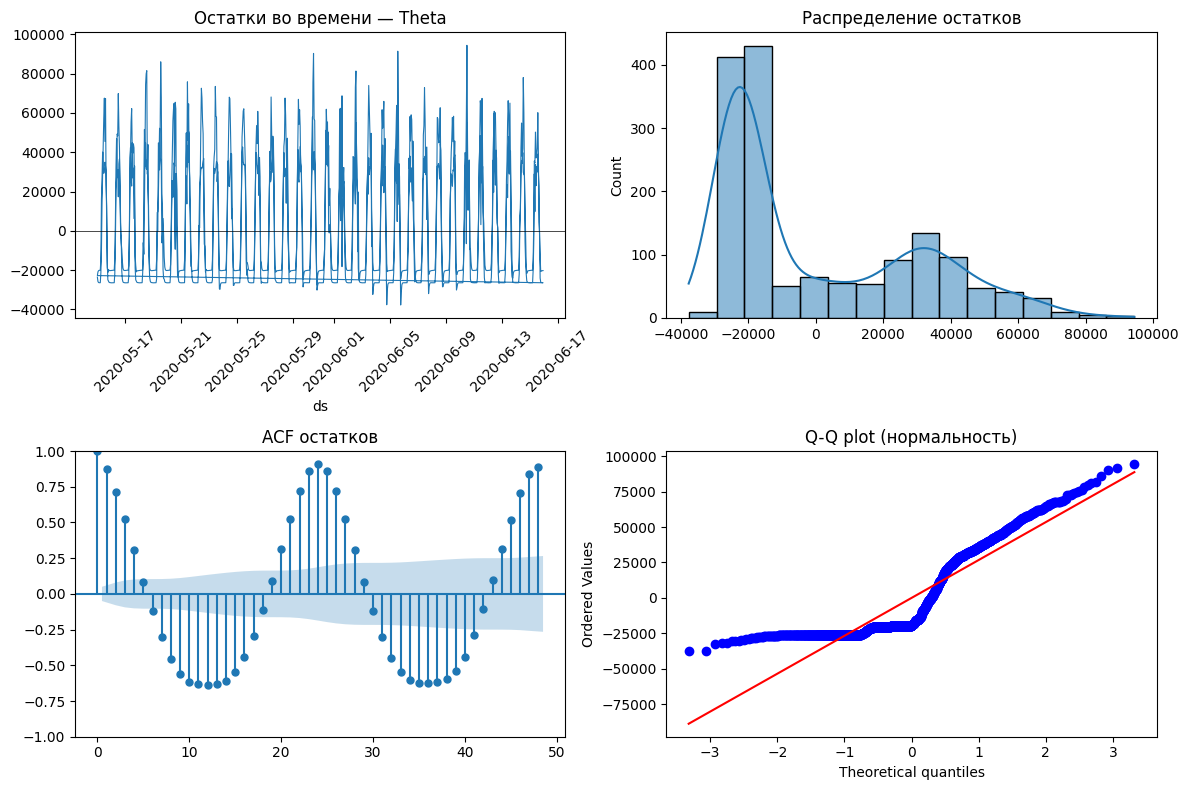

Ljung–Box (Theta):


,lb_stat,lb_pvalue
24,11316.710080,0.0
48,22466.707737,0.0


In [24]:
all_data = pd.concat([
    train_data.reset_index(drop=True),
    naive_train_forecasts.drop(['unique_id', 'ds', 'y'], axis=1),
    auto_train_forecasts.drop(['unique_id', 'ds', 'y'], axis=1),
    manual_train_forecasts.drop(['unique_id', 'ds', 'y'], axis=1)
], axis=1)

for model in [*naive_models, *auto_models, *manual_models]:
    name = model.alias

    d = all_data[[
        'unique_id',
        'ds',
        'y',
        name
    ]].dropna()

    plot_residual_diagnostics(
        d['ds'],
        d['y'],
        d[name],
        name
    )

## Backtest

Rolling cross-validation (`statsforecast.cross_validation`): горизонт **24 ч**, **5 окон**, шаг **24 ч** — оценка стабильности качества до финального hold-out на 48 ч.

Cross-validation: h=24, n_windows=5, step=24


,MAE,RMSE,MAPE,sMAPE
model,,,,
AutoTheta,5445.592868,9684.787313,1.618279e+09,104.425379
AutoETS,6025.784335,9933.443803,4.913608e+10,107.740548
AutoARIMA,6236.443640,11444.723837,2.577021e+05,35.740720
SeasonalNaive,6459.464420,12265.540880,1.620261e+01,15.351766
Naive,24679.086414,39952.069205,5.416667e+01,108.333333


model,AutoARIMA,AutoETS,AutoTheta,Naive,SeasonalNaive
cutoff,,,,,
2020-06-10 23:00:00,12674.03,12015.26,11913.31,33124.34,12981.77
2020-06-11 23:00:00,5162.04,7235.05,8261.57,34707.94,6668.29
2020-06-12 23:00:00,16844.36,11575.15,9686.43,49635.51,16409.67
2020-06-13 23:00:00,8166.28,8034.08,8051.28,41133.42,12687.77
2020-06-14 23:00:00,10826.36,9905.72,10007.23,39029.91,10438.79


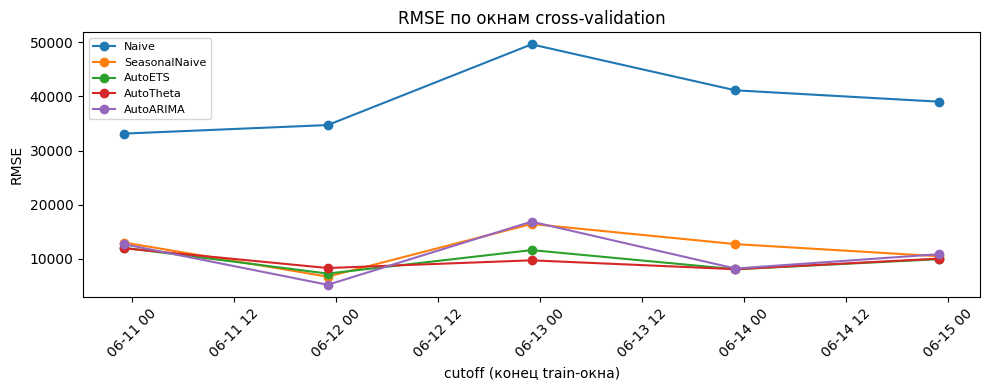

Лучшая модель по backtest (средний RMSE): AutoTheta


In [25]:
cv_models = [
    Naive(),
    SeasonalNaive(season_length=SEASON),
    AutoETS(season_length=SEASON),
    AutoTheta(season_length=SEASON),
    AutoARIMA(season_length=SEASON, max_p=3, max_q=3, max_P=1, max_Q=1),
]
cv_model_names = [m.alias for m in cv_models]

cv_data = train_data[train_data['unique_id'] == '1']
cv_results = cross_validate_models(
    cv_data,
    cv_models,
    h=CV_H,
    n_windows=N_WINDOWS,
    step_size=CV_STEP,
)

print(f'Cross-validation: h={CV_H}, n_windows={N_WINDOWS}, step={CV_STEP}')
cv_overall = cv_summary(cv_results, cv_model_names)
display(cv_overall)

cv_window_metrics = cv_by_window(cv_results, cv_model_names)
cv_pivot = cv_window_metrics.pivot(index='cutoff', columns='model', values='RMSE')
display(cv_pivot.round(2))

fig, ax = plt.subplots(figsize=(10, 4))
for name in cv_model_names:
    subset = cv_window_metrics[cv_window_metrics['model'] == name]
    ax.plot(subset['cutoff'], subset['RMSE'], marker='o', label=name)
ax.set_title('RMSE по окнам cross-validation')
ax.set_xlabel('cutoff (конец train-окна)')
ax.set_ylabel('RMSE')
ax.legend(loc='best', fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

best_cv_name = cv_overall.index[0]
print(f'Лучшая модель по backtest (средний RMSE): {best_cv_name}')